In [ ]:
# Week 1 Day 4 - Model Evaluation

## Goal

Understand why accuracy is not always enough.

## Topics

1. Confusion Matrix
2. Precision
3. Recall
4. F1-score

In [5]:
from sklearn.datasets import load_digits

digits = load_digits()

X = digits.data
y = digits.target

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1797, 64)
y shape: (1797,)


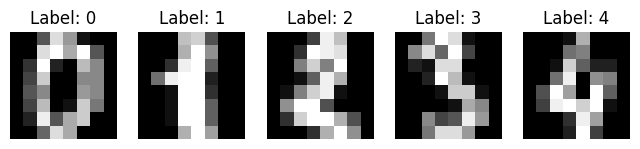

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

for i in range(5):
    plt.subplot(1, 5, i + 1)

    plt.imshow(
        digits.images[i],
        cmap="gray"
    )

    plt.title(f"Label: {digits.target[i]}")
    plt.axis("off")

plt.show()

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(1437, 64)
(360, 64)


In [8]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

model = KNeighborsClassifier(n_neighbors=3)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9861111111111112


In [9]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[36  0  0  0  0  0  0  0  0  0]
 [ 0 36  0  0  0  0  0  0  0  0]
 [ 0  0 35  0  0  0  0  0  0  0]
 [ 0  0  0 37  0  0  0  0  0  0]
 [ 0  0  0  0 36  0  0  0  0  0]
 [ 0  0  0  0  0 37  0  0  0  0]
 [ 0  0  0  0  0  0 36  0  0  0]
 [ 0  0  0  0  0  0  0 36  0  0]
 [ 0  3  0  0  0  0  0  0 32  0]
 [ 0  0  0  0  1  0  0  0  1 34]]


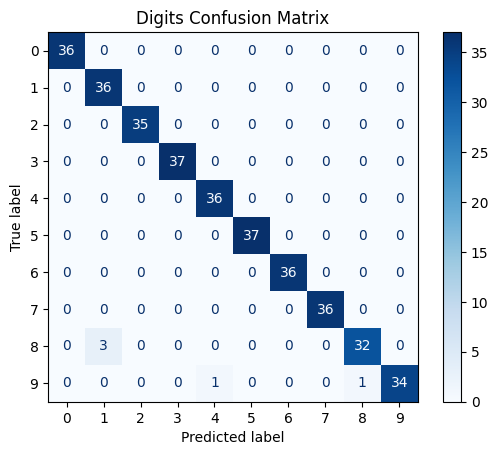

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Blues")

plt.title("Digits Confusion Matrix")

plt.show()

In [13]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.92      1.00      0.96        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       0.97      1.00      0.99        36
           5       1.00      1.00      1.00        37
           6       1.00      1.00      1.00        36
           7       1.00      1.00      1.00        36
           8       0.97      0.91      0.94        35
           9       1.00      0.94      0.97        36

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



In [ ]:
# Reflection

1. Why is accuracy not always enough?
Accuracy tells ue the overall performance of a model, but it does not explain which classses are misclassified. A model can achieve high 
accuracy while still making mistakes on specific classes.

2. What did I learn from confusion matrix?
The confusion matrix helped me identify where the model made mistakes. In my experiment, the model most often confused the digit 9 with the 
digit 1. This allowed me to perform error analysis instead of only looking at the accuracy score.

3. What do precision and recall mean?
Precision measures how many predicted samples of a class are actually correct.

Recall measures how many real samples of a class are successfully found by the model.

These metrics provide more detailed information than accuracy.

4. What did I learn today?
Today I learned hoe to evaluate a classification model using Accuracy, Confusion Matrix, Precision, Recall, F1-score, and Support. I also 
learned that model evaluation is not only about getting a high accuracy score, but also about understanding where and why mistakes happen.